#### Import Package

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.8 MB/s eta 0:00:00


#### Unzip the dataset

In [2]:
!unzip /content/drive/MyDrive/rider-helmet-no-helmet-lic-plate.v3-more-aug-and-pre-processing.yolov8.zip

Archive:  /content/drive/MyDrive/rider-helmet-no-helmet-lic-plate.v3-more-aug-and-pre-processing.yolov8.zip
 extracting: README.dataset.txt      
 extracting: README.roboflow.txt     
 extracting: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/OIP_jpeg.rf.37d0cf1c511ffd8d2f5d44c5d8cc9582.jpg  
 extracting: test/images/a-family-smile-to-the-camera-from-their-scooter-in-chennai-india-TCPHFG_jpg.rf.05ba798b6bc0d127920705884d0a796e.jpg  
 extracting: test/images/a-woman-with-her-pillion-rider-driving-her-scooter-through-busy-mohammed-ali-road-in-mumbai-india-a-man-pushing-his-pushcart-in-the-background-2E5F9W0_jpg.rf.e8b6efcb29c20b9715861152f75f052e.jpg  
 extracting: test/images/indian-females-ride-bicycles-and-males-drive-motorbikes-during-rush-hour-without-crash-helmets-in-traffic-puducherry-pondicherry-tamil-nadu-india-2G5Y80H_jpg.rf.d7997c085cb98f32b8bc12a6ac740860.jpg  
 extracting: test/images/people-riding-motorcycle-hyderabad-india-m

#### Train

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dad6214a150>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

#### Check weight

In [4]:
!ls runs/detect/train/weights

best.pt  last.pt


#### Test


image 1/5 /content/test/images/OIP_jpeg.rf.37d0cf1c511ffd8d2f5d44c5d8cc9582.jpg: 640x640 1 number plate, 1 rider, 1 without helmet, 11.4ms
image 2/5 /content/test/images/a-family-smile-to-the-camera-from-their-scooter-in-chennai-india-TCPHFG_jpg.rf.05ba798b6bc0d127920705884d0a796e.jpg: 640x640 1 number plate, 1 rider, 1 without helmet, 7.3ms
image 3/5 /content/test/images/a-woman-with-her-pillion-rider-driving-her-scooter-through-busy-mohammed-ali-road-in-mumbai-india-a-man-pushing-his-pushcart-in-the-background-2E5F9W0_jpg.rf.e8b6efcb29c20b9715861152f75f052e.jpg: 640x640 1 number plate, 1 rider, 1 with helmet, 1 without helmet, 7.2ms
image 4/5 /content/test/images/indian-females-ride-bicycles-and-males-drive-motorbikes-during-rush-hour-without-crash-helmets-in-traffic-puducherry-pondicherry-tamil-nadu-india-2G5Y80H_jpg.rf.d7997c085cb98f32b8bc12a6ac740860.jpg: 640x640 1 number plate, 3 riders, 4 without helmets, 7.2ms
image 5/5 /content/test/images/people-riding-motorcycle-hyderabad-i

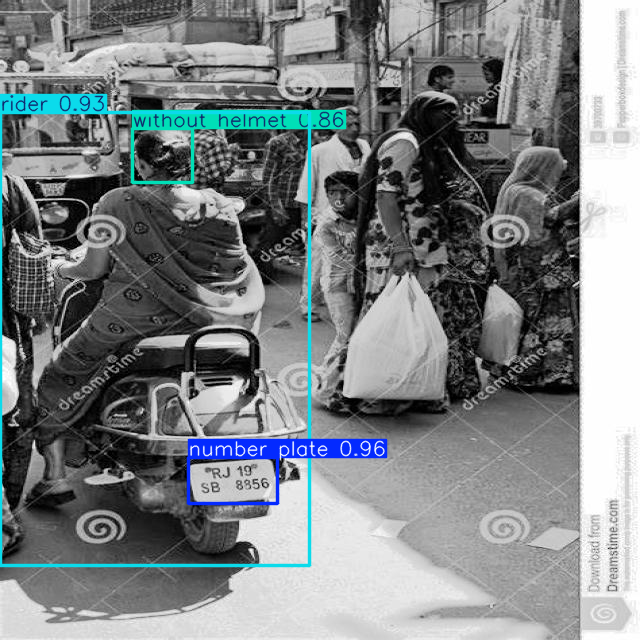

In [5]:
model = YOLO("runs/detect/train/weights/best.pt")

results = model("/content/test/images")

results[0].show()

#### Download best model

In [6]:
from google.colab import files
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>